# Notebook 01 — Traffic Congestion Metric Definition and Optimization Objectives

## Objective
Define the traffic-performance metrics that anchor the project’s congestion interpretation and establish operational quantities that can later support signal-timing optimization decisions.

## Dataset / Inputs
The notebook uses the processed daily and hourly traffic datasets created during preprocessing. Its outputs are derived traffic-flow metrics saved to `data/processed` for subsequent modeling and evaluation notebooks.

## Methodology
The analysis reviews the processed inputs, constructs congestion-oriented summary metrics, examines their empirical distributions, and derives peak-period operational proxies that connect descriptive traffic patterns to optimization objectives.

## Setup and Data Loading

We load both the daily and hourly processed outputs from the preprocessing notebook so that daily demand metrics and hourly operational proxies are defined from the same baseline.

In [41]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return start


repo_root = find_repo_root(Path.cwd())
daily_path = repo_root / "data" / "processed" / "modeling_dataset_2015_2019.csv"
hourly_path = repo_root / "data" / "processed" / "traffic_signal_hourly_dataset_2015_2019.csv"
output_path = repo_root / "data" / "processed" / "traffic_flow_metrics_2015_2019.csv"

for path in [daily_path, hourly_path]:
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run notebooks/00_raw_preprocessing.ipynb first.")

daily_df = pd.read_csv(daily_path, parse_dates=["date"])
hourly_df = pd.read_csv(hourly_path, parse_dates=["hour", "date"])

print(f"Loaded daily dataset: {daily_path}")
print(f"Loaded hourly dataset: {hourly_path}")
print(f"daily_df.shape: {daily_df.shape}")
print(f"hourly_df.shape: {hourly_df.shape}")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})


Loaded daily dataset: /Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting/data/processed/modeling_dataset_2015_2019.csv
Loaded hourly dataset: /Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting/data/processed/traffic_signal_hourly_dataset_2015_2019.csv
daily_df.shape: (5778, 16)
hourly_df.shape: (138672, 21)


## Data Understanding

We validate the available traffic flow fields before deriving optimization-oriented metrics.

In [42]:
print("Daily columns:", daily_df.columns.tolist())
print("\nDaily missing values:")
display(daily_df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nHourly columns:", hourly_df.columns.tolist())
print("\nHourly missing values:")
display(hourly_df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

required_daily_cols = [
    "location_id",
    "date",
    "daily_total_volume",
    "peak_hour_volume",
    "peak_ratio",
]
missing_required = [c for c in required_daily_cols if c not in daily_df.columns]
if missing_required:
    raise ValueError(f"Missing required daily columns: {missing_required}")


Daily columns: ['location_id', 'date', 'location_name', 'centreline_id', 'direction', 'year', 'month', 'day_of_week', 'is_weekend', 'daily_total_volume', 'peak_hour_volume', 'observed_hour_count', 'avg_observed_hourly_volume', 'peak_ratio', 'peak_hour_concentration', 'queue_pressure_proxy']

Daily missing values:


,missing_count
peak_ratio,1
peak_hour_concentration,1
location_id,0
date,0
location_name,0
centreline_id,0
direction,0
year,0
month,0
day_of_week,0



Hourly columns: ['location_id', 'hour', 'hourly_volume', 'location_name', 'centreline_id', 'direction', 'date', 'hour_of_day', 'year', 'month', 'day_of_week', 'is_weekend', 'daily_total_volume', 'peak_hour_volume', 'peak_ratio', 'peak_hour_concentration', 'observed_hour_count', 'hourly_share_of_daily_volume', 'is_peak_hour', 'estimated_arrival_rate_vph', 'estimated_arrival_rate_vpm']

Hourly missing values:


,missing_count
hourly_share_of_daily_volume,24
peak_hour_concentration,24
peak_ratio,24
location_id,0
is_weekend,0
estimated_arrival_rate_vph,0
is_peak_hour,0
observed_hour_count,0
peak_hour_volume,0
daily_total_volume,0


## Define Traffic Flow Metrics

The core metrics below are practical proxies for optimization-oriented analysis:
- `daily_total_volume`: daily throughput demand at a location
- `hourly_volume`: observed hour-level demand
- `peak_hour_volume`: highest hourly demand within a location-day
- `peak_ratio`: concentration of daily traffic in the busiest hour
- `peak_hour_concentration`: busiest hour relative to the average observed hour
- `traffic_demand_intensity`: location-normalized daily demand
- `queue_pressure_proxy`: excess peak-hour demand above the average observed hour
- `delay_pressure_proxy`: concentration pressure above a uniform-hour baseline

In [43]:
metric_df = daily_df.copy()
metric_df = metric_df.dropna(subset=["daily_total_volume", "peak_hour_volume", "peak_ratio"]).copy()
metric_df = metric_df[metric_df["daily_total_volume"] > 0].copy()

if "observed_hour_count" not in metric_df.columns:
    observed_hours = (
        hourly_df.groupby(["location_id", "date"], as_index=False)
        .agg(observed_hour_count=("hour", "nunique"))
    )
    metric_df = metric_df.merge(observed_hours, on=["location_id", "date"], how="left")

metric_df["avg_observed_hourly_volume"] = np.where(
    metric_df["observed_hour_count"] > 0,
    metric_df["daily_total_volume"] / metric_df["observed_hour_count"],
    np.nan,
)
metric_df["peak_hour_concentration"] = np.where(
    metric_df["avg_observed_hourly_volume"] > 0,
    metric_df["peak_hour_volume"] / metric_df["avg_observed_hourly_volume"],
    np.nan,
)
metric_df["traffic_demand_intensity"] = metric_df["daily_total_volume"] / (
    metric_df.groupby("location_id")["daily_total_volume"].transform("median")
)
metric_df["throughput_proxy"] = metric_df["daily_total_volume"]
metric_df["queue_pressure_proxy"] = (
    metric_df["peak_hour_volume"] - metric_df["avg_observed_hourly_volume"]
).clip(lower=0)
metric_df["delay_pressure_proxy"] = (
    metric_df["peak_hour_concentration"] - 1
).clip(lower=0)

summary_cols = [
    "daily_total_volume",
    "peak_hour_volume",
    "peak_ratio",
    "peak_hour_concentration",
    "traffic_demand_intensity",
    "queue_pressure_proxy",
    "delay_pressure_proxy",
]

display(metric_df[summary_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
daily_total_volume,5777.0,10877.726502,5834.647504,6.000000,7237.000000,10793.000000,14580.000000,40994.000000
peak_hour_volume,5777.0,929.926086,472.994378,3.000000,606.000000,926.000000,1230.000000,3047.000000
peak_ratio,5777.0,0.092307,0.029181,0.053244,0.077485,0.085522,0.097603,0.666667
peak_hour_concentration,5777.0,2.215368,0.700347,1.277862,1.859629,2.052523,2.342466,16.000000
traffic_demand_intensity,5777.0,0.991787,0.144750,0.001018,0.968215,1.000000,1.028431,1.866821
queue_pressure_proxy,5777.0,476.687482,257.728708,1.750000,291.166667,459.000000,628.083333,1782.500000
delay_pressure_proxy,5777.0,1.215368,0.700347,0.277862,0.859629,1.052523,1.342466,15.000000


## Distribution of Traffic Demand Metrics

These distributions show how overall demand, peak-hour loading, and concentration vary across location-days in the baseline dataset.

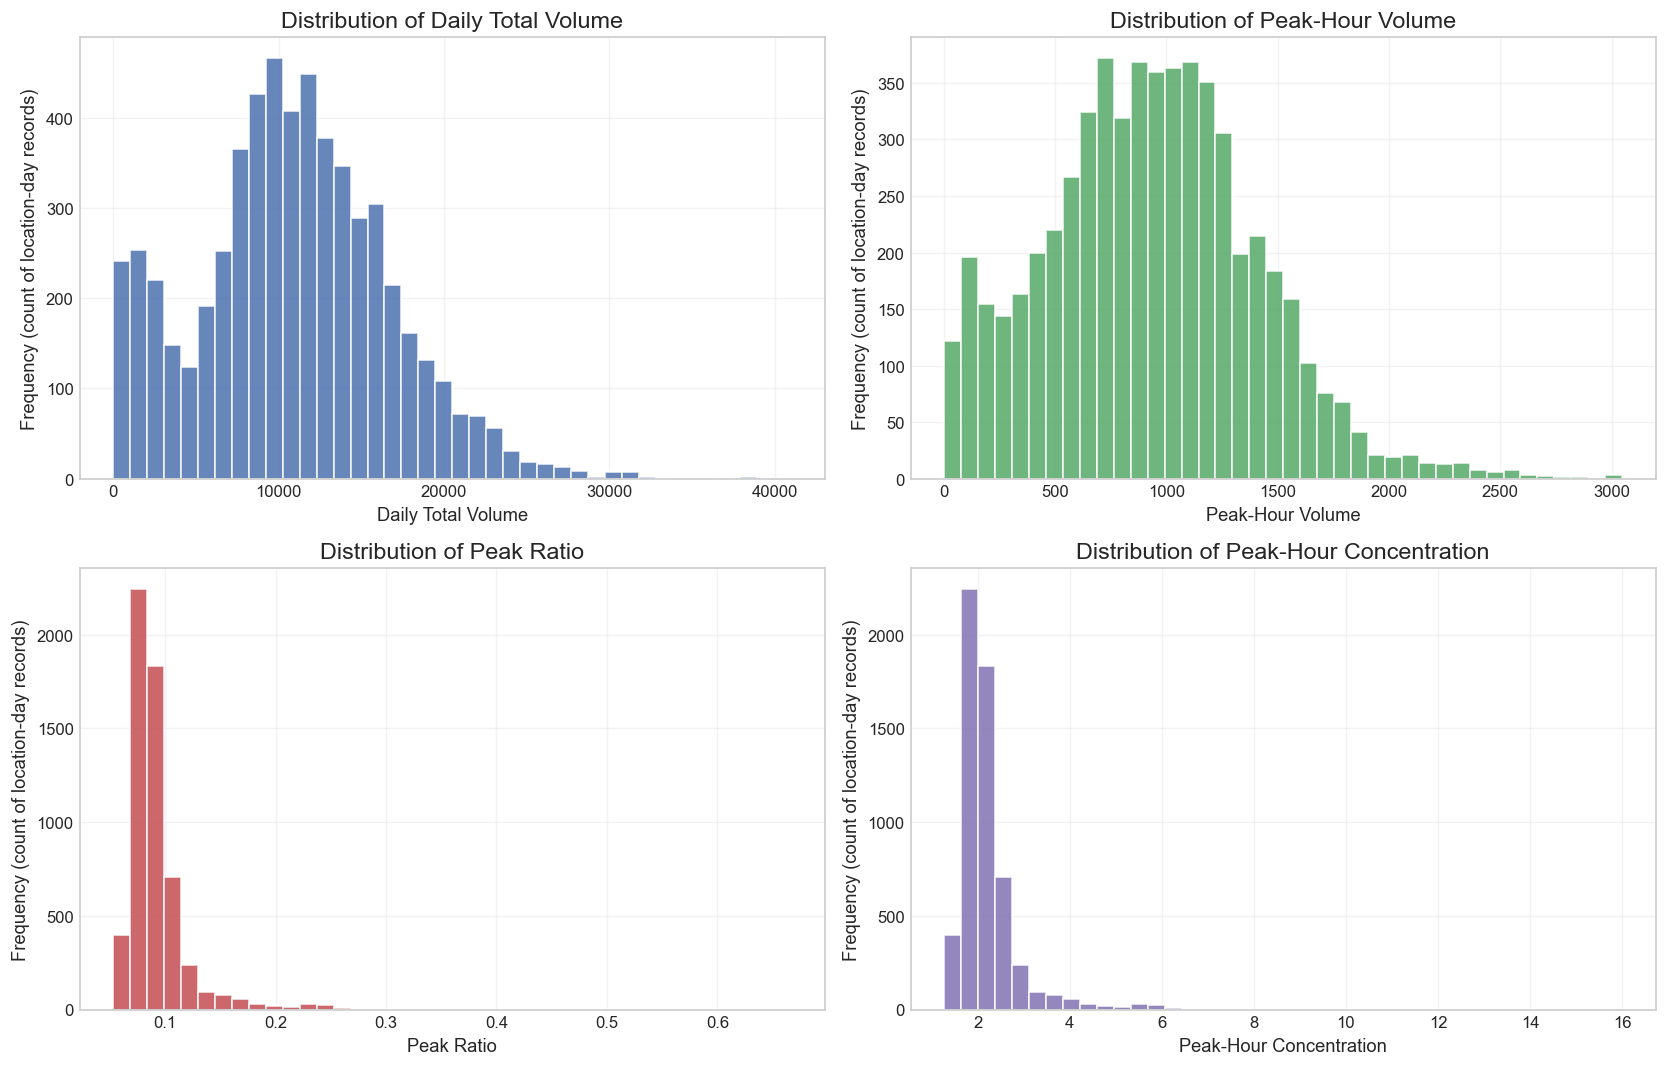

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_specs = [
    ("daily_total_volume", "Daily Total Volume", "#4C72B0"),
    ("peak_hour_volume", "Peak-Hour Volume", "#55A868"),
    ("peak_ratio", "Peak Ratio", "#C44E52"),
    ("peak_hour_concentration", "Peak-Hour Concentration", "#8172B2"),
]

for ax, (col, title, color) in zip(axes.flat, plot_specs):
    ax.hist(
        metric_df[col].dropna(),
        bins=40,
        color=color,
        edgecolor="white",
        alpha=0.85,
    )
    ax.set_title(f"Distribution of {title}")
    ax.set_xlabel(title)
    ax.set_ylabel("Frequency (count of location-day records)")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


### Visual Description
Each plot shows the distribution of a traffic demand metric across location-day records. The horizontal axis is the metric value (e.g., daily total volume), and the vertical axis is the number of location-day records that fall within each bin.

Because the distributions are often skewed, the histogram helps show how common typical values are versus how rare extreme values are, which is useful when prioritizing signal timing improvements for the most impactful congestion cases.

### Insight
A key takeaway from these charts is whether the metric is tightly clustered (most location-days behave similarly) versus stretched into a long tail (a small subset of location-days drive a lot of the extreme congestion). This helps prioritize which locations/date combinations are worth targeting with signal timing or planning interventions.

The highest planning value is not the absolute tail alone, but the concentration pattern. Locations with similar daily totals can still require different signal strategies if one site exhibits much sharper peak-hour concentration.

## Peak-Period Operational Proxies

Hour-level demand helps identify whether pressure is concentrated in the morning commute, evening commute, or outside the canonical peak windows.

Operational period definitions used in this notebook:
- **AM peak**: 07:00–09:00
- **PM peak**: 15:00–18:00
- **Off-peak**: all other hours

,peak_period,avg_hourly_volume,avg_hourly_share
0,AM peak,608.334891,0.056884
2,PM peak,779.514798,0.073021
1,Off-peak,348.987060,0.031604


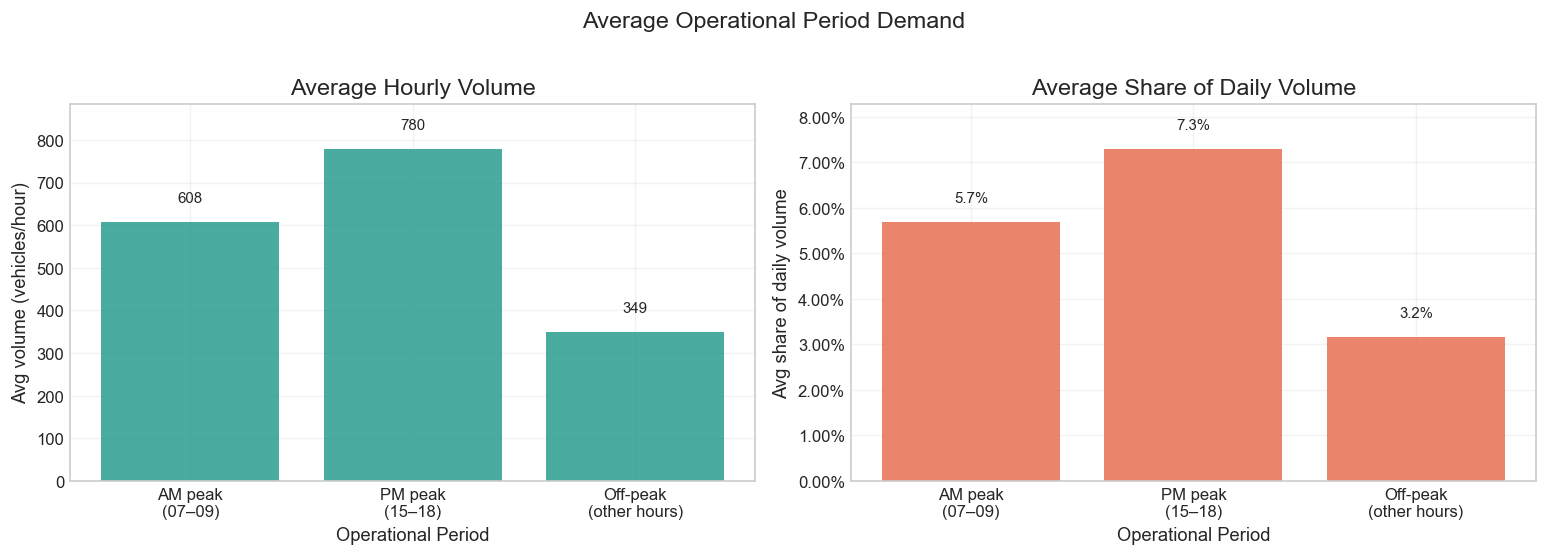

In [45]:
hourly_metrics = hourly_df.copy()
hourly_metrics = hourly_metrics.dropna(subset=["hourly_volume", "hour_of_day"]).copy()
hourly_metrics["peak_period"] = np.select(
    [
        hourly_metrics["hour_of_day"].between(7, 9),
        hourly_metrics["hour_of_day"].between(15, 18),
    ],
    ["AM peak", "PM peak"],
    default="Off-peak",
)

period_summary = (
    hourly_metrics.groupby("peak_period", as_index=False)
    .agg(
        avg_hourly_volume=("hourly_volume", "mean"),
        avg_hourly_share=("hourly_share_of_daily_volume", "mean"),
    )
)
period_order = ["AM peak", "PM peak", "Off-peak"]
period_summary["peak_period"] = pd.Categorical(
    period_summary["peak_period"],
    categories=period_order,
    ordered=True,
)
period_summary = period_summary.sort_values("peak_period")
display(period_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Average Operational Period Demand", fontsize=14, y=1.02)

period_labels = [
    "AM peak\n(07–09)",
    "PM peak\n(15–18)",
    "Off-peak\n(other hours)",
]

bars0 = axes[0].bar(
    period_summary["peak_period"].astype(str),
    period_summary["avg_hourly_volume"],
    color="#2A9D8F",
    alpha=0.85,
)
axes[0].set_title("Average Hourly Volume")
axes[0].set_xlabel("Operational Period")
axes[0].set_xticks(range(len(period_labels)))
axes[0].set_xticklabels(period_labels)
axes[0].set_ylabel("Avg volume (vehicles/hour)")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].grid(True, alpha=0.25)

bars1 = axes[1].bar(
    period_summary["peak_period"].astype(str),
    period_summary["avg_hourly_share"],
    color="#E76F51",
    alpha=0.85,
)
axes[1].set_title("Average Share of Daily Volume")
axes[1].set_xlabel("Operational Period")
axes[1].set_xticks(range(len(period_labels)))
axes[1].set_xticklabels(period_labels)
axes[1].set_ylabel("Avg share of daily volume")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2%}"))
axes[1].grid(True, alpha=0.25)

for bar in bars0:
    height = bar.get_height()
    axes[0].annotate(
        f"{height:,.0f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

for bar in bars1:
    height = bar.get_height()
    axes[1].annotate(
        f"{height:.1%}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Add a small headroom so annotations do not overlap the top of the plot
for ax in axes:
    y0, y1 = ax.get_ylim()
    ax.set_ylim(y0, y1 * 1.08)

plt.tight_layout()
plt.show()


### Visual Description
This visual presents average hourly volume by operational period and average share of daily volume by operational period. The horizontal axis reports operational period, and the vertical axis reports average hourly volume and average hourly share of daily volume. Together, the figure provides a direct summary of the traffic pattern, model comparison, or operational outcome under study.

### Insight
The main value of this visual is that it makes relative differences immediately visible, which helps confirm whether the chosen congestion metrics capture both recurring demand intensity and the operational pressure that matters for signal control. That perspective supports clearer discussion of congestion conditions, forecasting performance, and signal-timing decisions during presentation.

AM and PM peak summaries help target where fixed-time plans or time-of-day plans are most justified. A stronger PM concentration, for example, suggests signal timing should prioritize outbound or commuter-heavy release periods.

## Save the Traffic Flow Metrics Table

This output becomes a clean metrics layer for later baseline signal timing, optimization, and simulation notebooks.

In [46]:
# Ensure metric_df exists from earlier notebook cells (type-checkers may not infer cross-cell state)
metric_df = globals().get("metric_df")
if metric_df is None:
    raise RuntimeError("metric_df not found; run the metric calculation cells first")

metric_output_cols = [
    "location_id",
    "location_name",
    "centreline_id",
    "direction",
    "date",
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "observed_hour_count",
    "daily_total_volume",
    "peak_hour_volume",
    "peak_ratio",
    "avg_observed_hourly_volume",
    "peak_hour_concentration",
    "traffic_demand_intensity",
    "throughput_proxy",
    "queue_pressure_proxy",
    "delay_pressure_proxy",
]
metric_output_cols = [c for c in metric_output_cols if c in metric_df.columns]
metric_df = metric_df.loc[:, metric_output_cols].sort_values(["location_id", "date"]).reset_index(drop=True)
metric_df.to_csv(output_path, index=False)

print(f"Saved file: {output_path}")
print(f"Rows: {metric_df.shape[0]:,}")
print(f"Columns: {metric_df.shape[1]}")
display(metric_df.head())


Saved file: /Users/manavparikh/Documents/GitHub/unfc-capstone-traffic-forecasting/data/processed/traffic_flow_metrics_2015_2019.csv
Rows: 5,777
Columns: 19


,location_id,location_name,centreline_id,direction,date,year,month,day_of_week,is_weekend,observed_hour_count,daily_total_volume,peak_hour_volume,peak_ratio,avg_observed_hourly_volume,peak_hour_concentration,traffic_demand_intensity,throughput_proxy,queue_pressure_proxy,delay_pressure_proxy
0,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-14,2015,5,3,0,24,17031,1809,0.106218,709.625000,2.549234,1.392502,17031,1099.375000,1.549234
1,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-15,2015,5,4,0,24,17365,1734,0.099856,723.541667,2.396545,1.419811,17365,1010.458333,1.396545
2,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-16,2015,5,5,1,24,14470,1066,0.073670,602.916667,1.768072,1.183108,14470,463.083333,0.768072
3,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-17,2015,5,6,1,24,12235,973,0.079526,509.791667,1.908623,1.000368,12235,463.208333,0.908623
4,10010625_WB,Danforth Ave: Donlands Ave - Byron Ave,10010625,WB,2015-05-18,2015,5,0,0,24,16523,1775,0.107426,688.458333,2.578224,1.350967,16523,1086.541667,1.578224


## Outputs

- Input used: `data/processed/modeling_dataset_2015_2019.csv`
- Input used: `data/processed/traffic_signal_hourly_dataset_2015_2019.csv`
- New output: `data/processed/traffic_flow_metrics_2015_2019.csv`